###Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Extract Landmark from Dataset

In [2]:
!pip uninstall mediapipe
!pip install mediapipe==0.10.14
!pip uninstall protobuf
!pip install protobuf==5.29.1

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/mediapipe-0.10.14.dist-info/*
    /usr/local/lib/python3.12/dist-packages/mediapipe.libs/libEGL-29b68110.so.1.1.0
    /usr/local/lib/python3.12/dist-packages/mediapipe.libs/libGLESv2-3a91e100.so.2.1.0
    /usr/local/lib/python3.12/dist-packages/mediapipe.libs/libGLdispatch-dcc1ca97.so.0.0.0
    /usr/local/lib/python3.12/dist-packages/mediapipe/*
Proceed (Y/n)? Y
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)
Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl (295 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.1

Found existing installation: protobuf 4.25.9
Uninstalling protobuf-4.25.9:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/google/_upb/_message.abi3.so
    /usr/local/lib/python3.12/dist-packages/google/protobuf/*
    /usr/local/lib/python3.12/dist-packages/protobuf-4.25.9.dist-info/*
Proceed (Y/n)? Y
  Successfully uninstalled protobuf-4.25.9
  Using cached protobuf-5.29.1-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
Using cached protobuf-5.29.1-cp38-abi3-manylinux2014_x86_64.whl (319 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.1 which is incompatible.


In [3]:
import cv2
import mediapipe as mp
import numpy as np
import os
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [5]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.3)

In [6]:
PATH = '/content/drive/MyDrive/Semester 4/Artificial Intelligence/AOL_SIBI/dataset'
print(os.listdir(PATH))
SUBJECTS = ['Sinta', 'Kaggle', 'Roger', 'Michael']

MODEL_PATH = '/content/drive/MyDrive/Semester 4/Artificial Intelligence/AOL_SIBI/Model'

['Sinta', 'Kaggle', 'Roger', 'Michael']


In [7]:
def normalize_lm(feature):
  lm = np.array(feature).reshape(21,3)
  wrist = lm[0]
  lm = lm - wrist
  scale = np.max(np.abs(lm))
  if scale > 0:
    lm = lm / scale
  return lm.flatten().tolist()

In [8]:
# data_train = []
# labels_train = []
# subject_train = []

# data_test = []
# labels_test = []
# subject_test = []

# for subject in SUBJECTS:
#   subject_path = os.path.join(PATH, subject)

#   for alphabet in os.listdir(subject_path):
#     alphabet_path = os.path.join(subject_path, alphabet)

#     if not os.path.isdir(alphabet_path):
#       continue

#     for img_file in os.listdir(alphabet_path):
#       img_path = os.path.join(alphabet_path, img_file)

#       if not os.path.isfile(img_path):
#         continue

#       img = cv2.imread(img_path)

#       if img is None:
#         continue

#       img = cv2.resize(img, (224,224))
#       img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#       result = hands.process(img_rgb)

#       if result.multi_hand_landmarks:
#         landmarks = result.multi_hand_landmarks[0]

#         features = []
#         for lm in landmarks.landmark:
#           features.extend([lm.x, lm.y, lm.z])

#         features = normalize_lm(features)

#         if subject == "Kaggle":
#           data_train.append(features)
#           labels_train.append(alphabet)
#           subject_train.append(subject)
#           continue

#         data_test.append(features)
#         labels_test.append(alphabet)
#         subject_test.append(subject)

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [9]:
# print(f"Total data train yang berhasil: {len(data_train)}")
# print(f"Total data test yang berhasil: {len(data_test)}")

Total data train yang berhasil: 2779
Total data test yang berhasil: 2941


In [10]:
# df_train = pd.DataFrame(data_train)
# df_train['label'] = labels_train
# df_train['subject'] = subject_train

# df_test = pd.DataFrame(data_test)
# df_test['label'] = labels_test
# df_test['subject'] = subject_test

# # Gabung sebagian yang manual dengan dataset kaggle
# df_manual_test, df_manual_train = train_test_split(df_test, test_size=0.2, random_state=42, stratify=df_test['label'])

# df_train = pd.concat([df_train, df_manual_train]).reset_index(drop=True)
# df_test = df_manual_test.reset_index(drop=True)

# df_train = shuffle(df_train, random_state=42).reset_index(drop=True)

# df_train.to_csv(os.path.join(MODEL_PATH, 'dataset_training.csv'), index=False)
# print(df_train.shape)

# df_test.to_csv(os.path.join(MODEL_PATH, 'dataset_testing.csv'), index=False)
# print(df_test.shape)

(3368, 65)
(2352, 65)


In [11]:
df_train = pd.read_csv(os.path.join(MODEL_PATH, 'dataset_training.csv'), sep=',')
print(df_train.shape)

df_test = pd.read_csv(os.path.join(MODEL_PATH, 'dataset_testing.csv'), sep=',')
print(df_test.shape)

(3368, 65)
(2352, 65)


In [12]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,label,subject
0,0.0,0.0,0.0,0.122185,-0.086267,-0.074619,0.172147,-0.272177,-0.097587,0.098533,...,-0.334927,-0.234442,-0.110998,-0.225669,-0.248220,-0.054500,-0.152772,-0.225676,R,Sinta
1,0.0,0.0,0.0,0.247643,-0.226928,-0.058559,0.371751,-0.555931,-0.080751,0.249114,...,-0.838687,-0.148186,-0.155313,-0.676776,-0.092612,-0.149802,-0.553598,-0.035535,S,Kaggle
2,0.0,0.0,0.0,-0.116079,-0.186509,-0.059587,-0.354609,-0.304617,-0.055853,-0.524774,...,0.093752,-0.145776,-0.354280,0.050032,-0.132207,-0.298434,0.050490,-0.101636,H,Kaggle
3,0.0,0.0,0.0,0.141650,-0.106968,-0.064950,0.222979,-0.301803,-0.092551,0.167198,...,-0.454107,-0.206603,-0.053569,-0.355196,-0.194895,-0.029584,-0.253035,-0.161351,R,Kaggle
4,0.0,0.0,0.0,-0.225083,0.132333,-0.199180,-0.360991,0.366079,-0.295162,-0.318311,...,0.639931,-0.261564,-0.130927,0.787025,-0.292442,-0.143328,0.913566,-0.309206,Q,Kaggle


In [13]:
df_test.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,label,subject
0,0.0,0.0,0.0,0.145583,-0.098221,-0.068551,0.239561,-0.246715,-0.110513,0.344676,...,-0.529348,-0.149317,-0.126192,-0.439883,-0.120213,-0.104023,-0.355929,-0.080471,L,Sinta
1,0.0,0.0,0.0,0.002479,-0.073580,-0.357770,0.119146,-0.235930,-0.435870,0.303042,...,-0.426608,-0.003630,0.481827,-0.302017,-0.056798,0.375942,-0.252366,-0.042877,X,Michael
2,0.0,0.0,0.0,0.227200,-0.136106,-0.067016,0.346807,-0.366754,-0.080959,0.250429,...,-0.756325,-0.071333,-0.243269,-0.711578,-0.042573,-0.211023,-0.622947,-0.005296,E,Sinta
3,0.0,0.0,0.0,0.008442,-0.105793,-0.185242,0.001811,-0.312926,-0.212223,-0.029029,...,-0.294656,-0.040317,-0.218304,-0.199501,-0.066125,-0.163683,-0.144740,-0.051319,K,Sinta
4,0.0,0.0,0.0,-0.132954,0.184001,-0.343391,-0.322878,0.461094,-0.383798,-0.377898,...,0.563574,0.321148,-0.378299,0.514955,0.239604,-0.324662,0.416571,0.227764,Q,Michael


In [14]:
print("Jumlah data tiap huruf dalam dataset training:")
print(df_train['label'].value_counts().sort_index())

print("\nJumlah data tiap huruf dalam dataset testing:")
print(df_test['label'].value_counts().sort_index())

Jumlah data tiap huruf dalam dataset training:
label
A    169
B    153
C    128
D    145
E    174
F    148
G    128
H    129
I    141
K    144
L    140
M    150
N    142
O    132
P    106
Q     92
R    147
S    151
T    146
U    137
V    135
W    131
X    161
Y    139
Name: count, dtype: int64

Jumlah data tiap huruf dalam dataset testing:
label
A    100
B     96
C     90
D     76
E    102
F    108
G     58
H     75
I     89
K    107
L    103
M    111
N     92
O     81
P     86
Q     98
R    105
S     87
T    117
U    101
V    109
W    128
X    116
Y    117
Name: count, dtype: int64


In [15]:
print("Asal tiap data training per subject:")
print(df_train.groupby(['subject', 'label']).size().unstack(fill_value=0))

print("\nAsal tiap data testing per subject:")
print(df_test.groupby(['subject', 'label']).size().unstack(fill_value=0))

Asal tiap data training per subject:
label      A    B    C    D    E    F    G    H    I    K  ...   P   Q    R  \
subject                                                    ...                
Kaggle   144  129  106  126  148  121  113  110  119  117  ...  84  68  121   
Michael    7    4    5    2    8    8    5    7    5    6  ...   9  10    9   
Roger     10    8    4    4   11    8    0    4    6   12  ...   6   3    8   
Sinta      8   12   13   13    7   11   10    8   11    9  ...   7  11    9   

label      S    T    U    V   W    X    Y  
subject                                    
Kaggle   129  117  111  108  99  132  110  
Michael   11    7    3   11  15   11   13  
Roger      2   12    8    6  11    7    9  
Sinta      9   10   15   10   6   11    7  

[4 rows x 24 columns]

Asal tiap data testing per subject:
label     A   B   C   D   E   F   G   H   I   K  ...   P   Q   R   S   T   U  \
subject                                          ...                           
Mich

###Data Preparation and Building Learning Model

####Data Splitting and Encoding the Label

In [16]:
x = df_train.drop(['label', 'subject'], axis=1).values
y = df_train['label'].values

x_test = df_test.drop(['label', 'subject'], axis=1).values
y_test = df_test['label'].values

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
label_encode = LabelEncoder()
label_encode.fit(sorted(df_train['label'].unique()))
y_train_encode = label_encode.transform(y_train)
y_val_encode = label_encode.transform(y_val)
y_test_encode = label_encode.transform(y_test)

In [18]:
print(f"Train Size: {x_train.shape}")
print(f"Validation Size: {x_val.shape}")
print(f"Test Size: {x_test.shape}")

Train Size: (2694, 63)
Validation Size: (674, 63)
Test Size: (2352, 63)


In [19]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [20]:
def conf_matrix(y_actual, y_predict, name):
  labels_decoded = sorted(df_train['label'].unique())
  labels_encoded = label_encode.transform(labels_decoded)

  cm = confusion_matrix(y_actual, y_predict, labels=labels_encoded)

  plt.figure(figsize=(16, 14))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=labels_decoded, yticklabels=labels_decoded)
  plt.title(f"Confusion Matrix of {name} Model")
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.tight_layout()
  plt.savefig(os.path.join(MODEL_PATH, f"confusion_matrix_{name}.png"), dpi=150)
  plt.show()

In [21]:
def plot_learning_curve(model, x, y, name):
  train_size, train_score, val_score = learning_curve(model, x, y,
                                                      train_sizes=np.linspace(0.1, 1, 10),
                                                      cv=cv, scoring='accuracy', n_jobs=1)

  train_mean = train_score.mean(axis=1)
  val_mean = val_score.mean(axis=1)

  plt.figure(figsize=(6,4))
  plt.plot(train_size, train_mean, 'o--', label='Train Accuracy', color='darkblue')
  plt.plot(train_size, val_mean, 'o--', label='Validation Accuracy', color='red')
  plt.title(f"Learning Curve of {name} Model")
  plt.xlabel("Jumlah Data Training")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.tight_layout()
  plt.savefig(os.path.join(MODEL_PATH, f"learning_curve_{name}.png"), dpi=150)
  plt.show()

####KNN Classifier

In [22]:
param_KNN = {
    'n_neighbors' : [10, 15, 20],
    'weights' : ['uniform', 'distance'],
    'metric' : ['euclidean', 'manhattan']
}

Best Parameter for KNN: {'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'distance'}
Best CV Score for KNN: 0.9198
Accuracy KNN train: 1.0
Accuracy KNN validation: 0.9065
Accuracy KNN test: 0.8325
Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       100
           1       0.75      0.91      0.82        96
           2       0.75      0.89      0.82        90
           3       0.87      0.87      0.87        76
           4       0.92      0.95      0.94       102
           5       0.95      0.67      0.78       108
           6       0.82      0.97      0.89        58
           7       0.95      0.92      0.93        75
           8       0.93      0.74      0.82        89
           9       0.97      0.71      0.82       107
          10       0.88      0.96      0.92       103
          11       0.89      0.50      0.64       111
          12       0.80      0.74      0.77        92
          

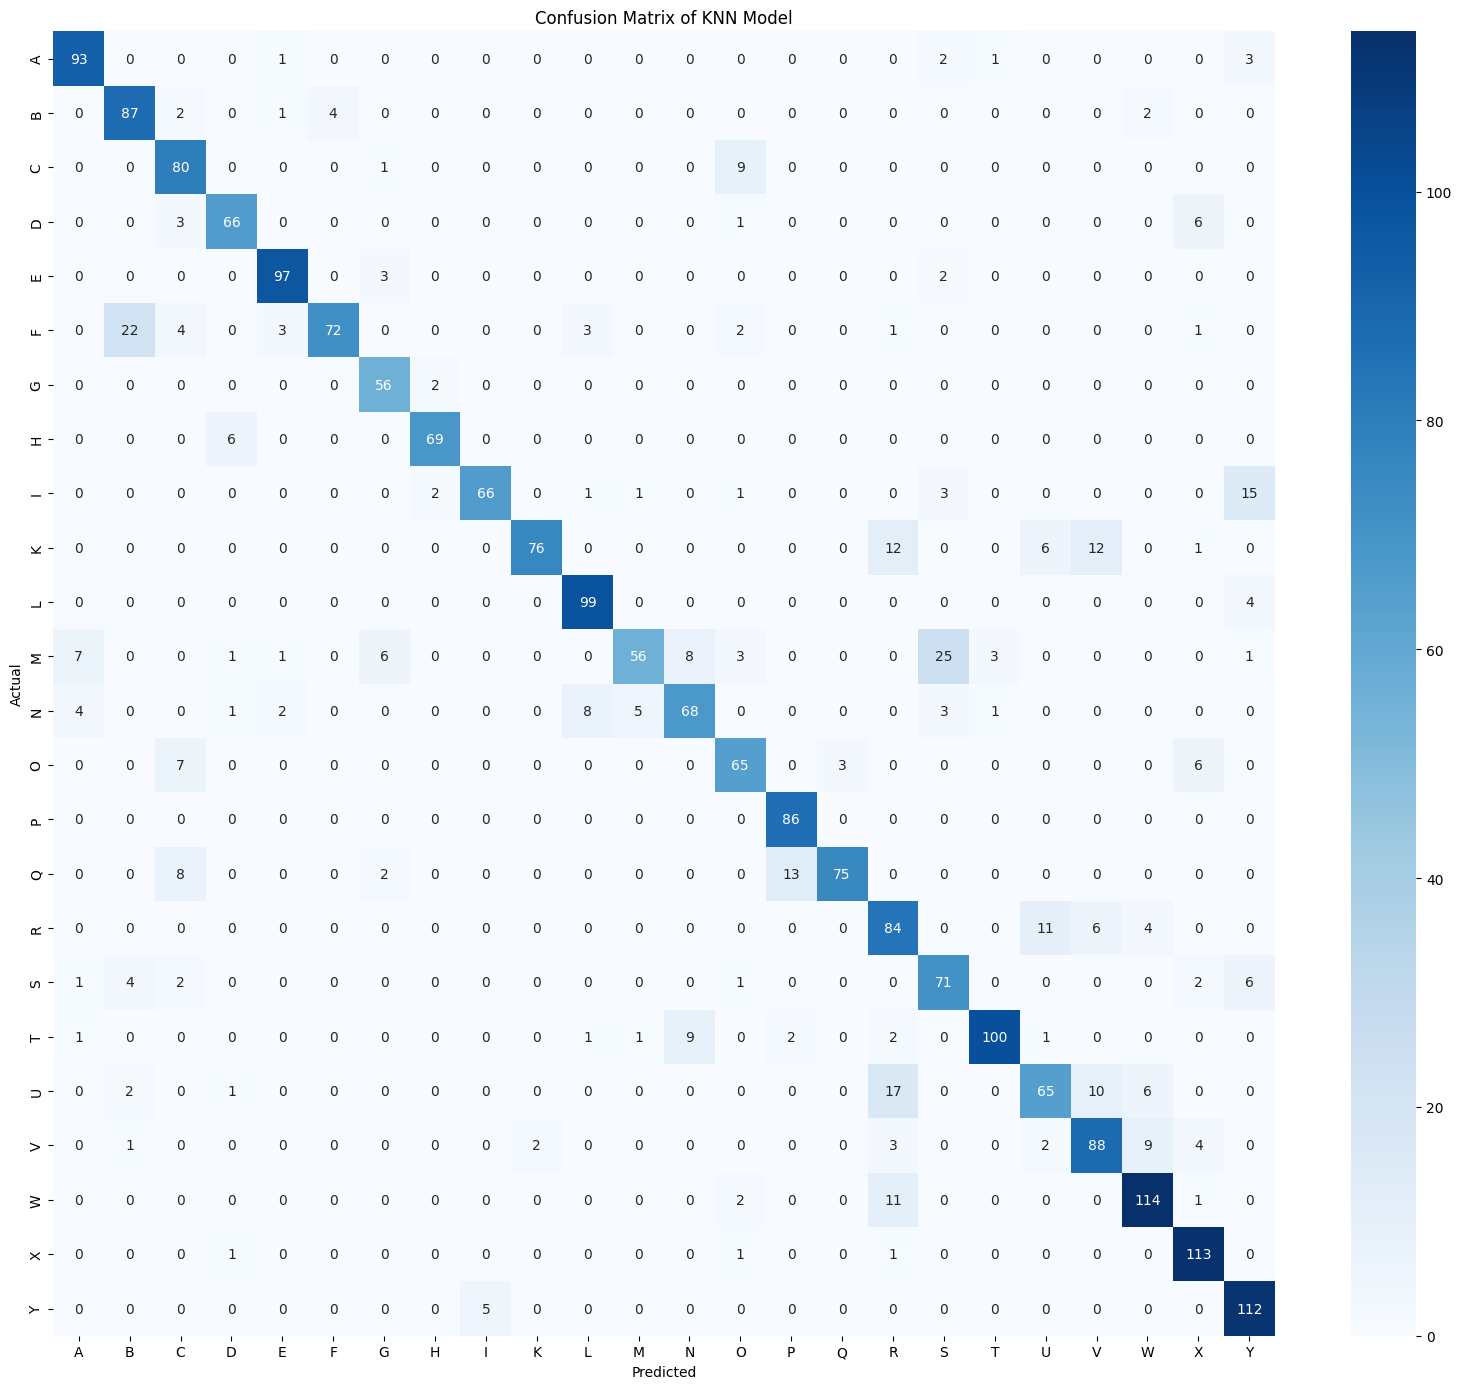

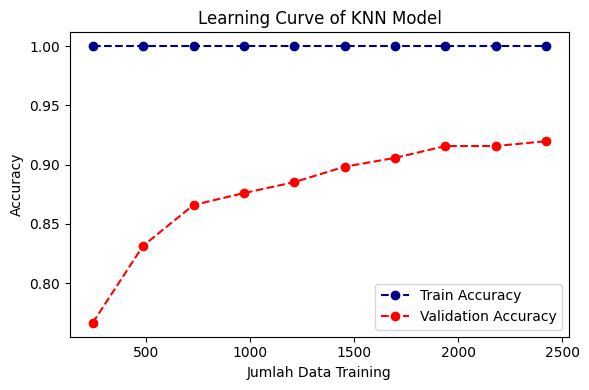

In [23]:
KNN = KNeighborsClassifier()

grid_KNN = GridSearchCV(KNN, param_KNN, scoring='accuracy', cv=cv, n_jobs=1, error_score=0)

grid_KNN.fit(x_train, y_train_encode)

print(f"Best Parameter for KNN: {grid_KNN.best_params_}")
print(f"Best CV Score for KNN: {round(grid_KNN.best_score_, 4)}")

KNN_model = grid_KNN.best_estimator_
acc_KNN_train = accuracy_score(y_train_encode, KNN_model.predict(x_train))
acc_KNN_val = accuracy_score(y_val_encode, KNN_model.predict(x_val))
acc_KNN_test = accuracy_score(y_test_encode, KNN_model.predict(x_test))

print(f"Accuracy KNN train: {round(acc_KNN_train, 4)}")
print(f"Accuracy KNN validation: {round(acc_KNN_val, 4)}")
print(f"Accuracy KNN test: {round(acc_KNN_test, 4)}")

print(f"Classification Report for KNN:")
print(classification_report(y_test_encode, KNN_model.predict(x_test)))

conf_matrix(y_test_encode, KNN_model.predict(x_test), 'KNN')
plot_learning_curve(KNN_model, x_train, y_train_encode, "KNN")

####Random Forest Classifier

In [24]:
param_RF = {
    'n_estimators' : [100, 200, 500],
    'max_depth' : [5, 8],
    'min_samples_split' : [20, 30],
    'min_samples_leaf' : [10, 20],
    'max_features' : ['sqrt', 'log2']
}

Best Parameter for RF: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 500}
Best CV Score for RF: 0.9068
Accuracy RF train: 0.9414
Accuracy RF validation: 0.9095
Accuracy RF test: 0.8461
Classification Report for RF:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       100
           1       0.94      0.96      0.95        96
           2       0.87      0.80      0.83        90
           3       0.70      0.83      0.76        76
           4       0.94      0.94      0.94       102
           5       0.95      0.96      0.96       108
           6       0.65      0.88      0.74        58
           7       0.96      0.88      0.92        75
           8       0.87      0.90      0.88        89
           9       0.90      0.94      0.92       107
          10       0.77      0.99      0.86       103
          11       0.96      0.72      0.82       111
          12       0.8

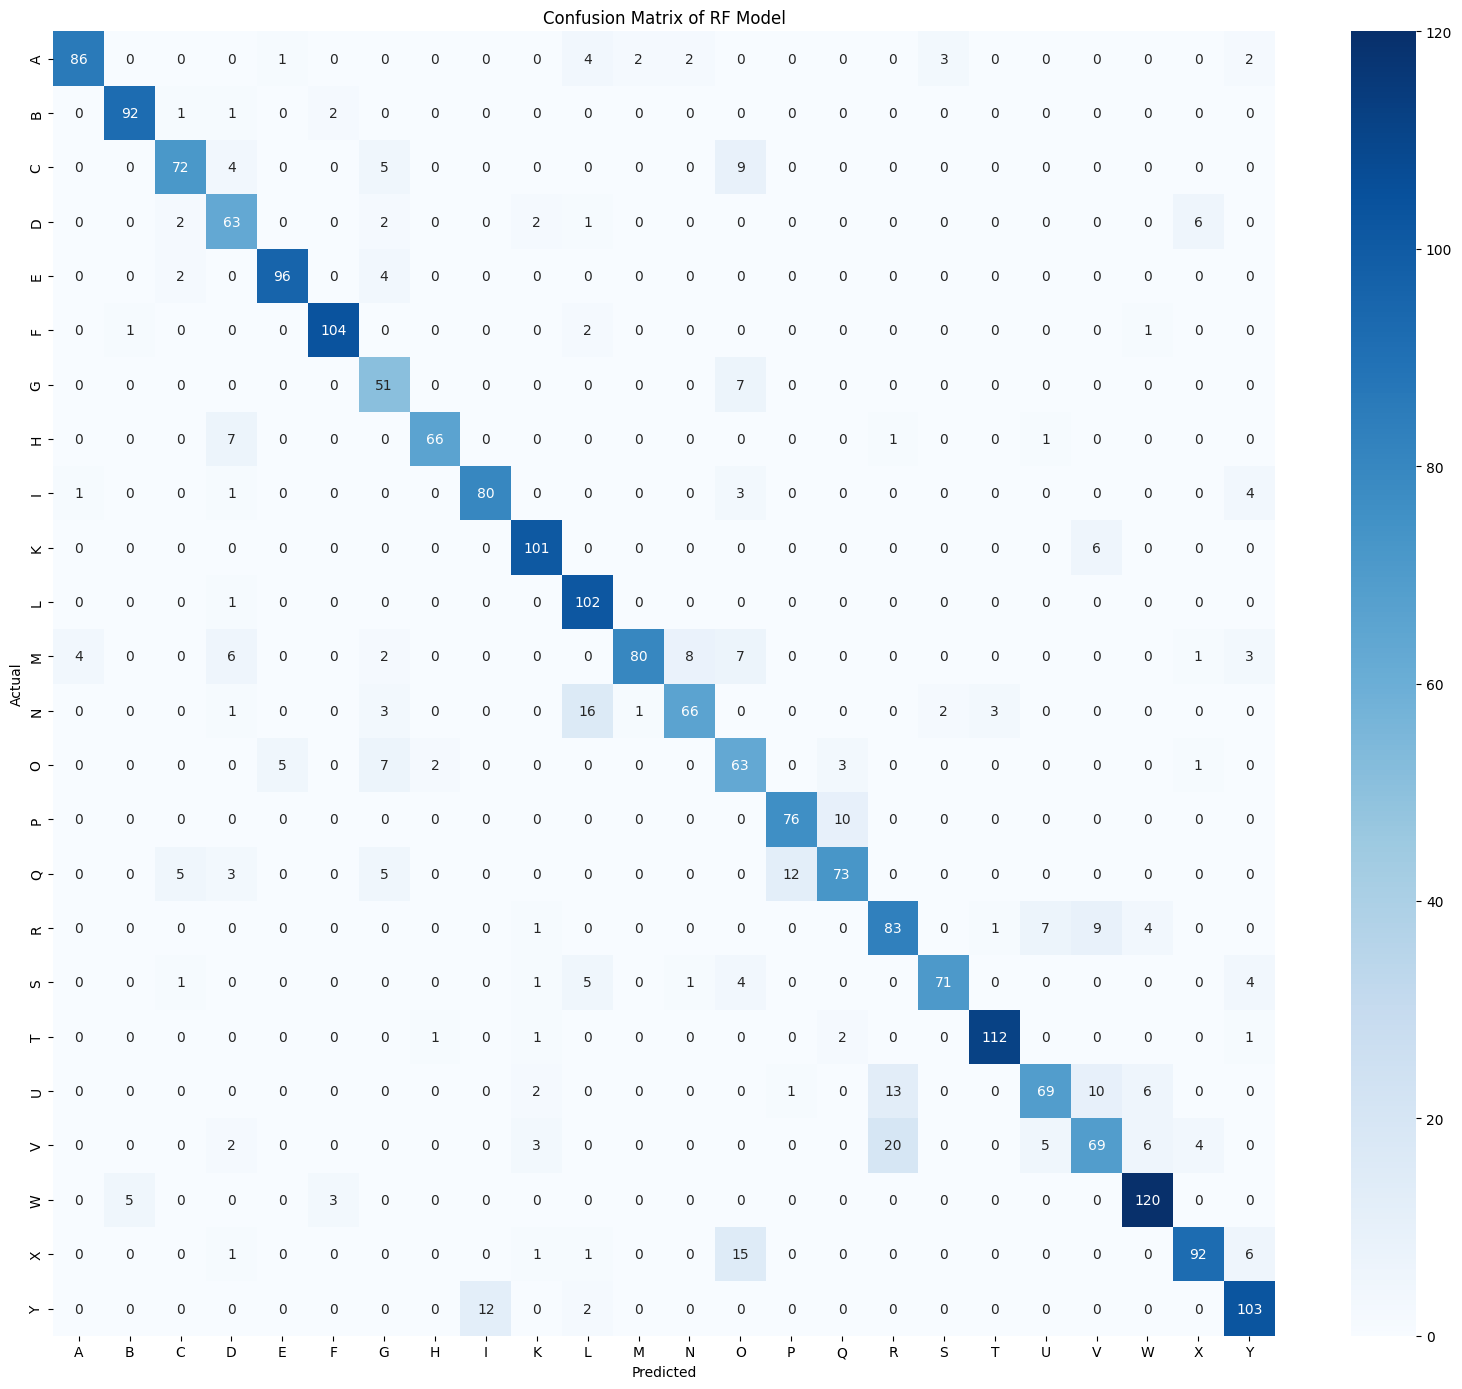

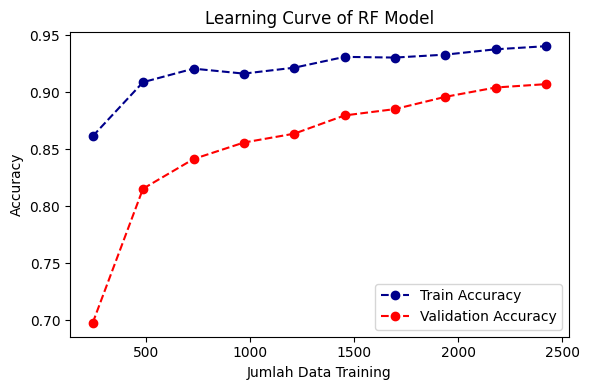

In [25]:
RF = RandomForestClassifier(random_state=42)
grid_RF = GridSearchCV(RF, param_RF, scoring='accuracy', cv=cv, n_jobs=1)

grid_RF.fit(x_train, y_train_encode)

print(f"Best Parameter for RF: {grid_RF.best_params_}")
print(f"Best CV Score for RF: {round(grid_RF.best_score_, 4)}")

RF_model = grid_RF.best_estimator_
acc_RF_train = accuracy_score(y_train_encode, RF_model.predict(x_train))
acc_RF_val = accuracy_score(y_val_encode, RF_model.predict(x_val))
acc_RF_test = accuracy_score(y_test_encode, RF_model.predict(x_test))

print(f"Accuracy RF train: {round(acc_RF_train, 4)}")
print(f"Accuracy RF validation: {round(acc_RF_val, 4)}")
print(f"Accuracy RF test: {round(acc_RF_test, 4)}")

print(f"Classification Report for RF:")
print(classification_report(y_test_encode, RF_model.predict(x_test)))

conf_matrix(y_test_encode, RF_model.predict(x_test), 'RF')
plot_learning_curve(RF_model, x_train, y_train_encode, 'RF')

####Ensemble Voting

Accuracy Ensemble train: 1.0
Accuracy Ensemble validation: 0.9169
Accuracy Ensemble test: 0.8724
Classification Report for Ensemble:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       100
           1       0.95      0.96      0.95        96
           2       0.78      0.89      0.83        90
           3       0.86      0.86      0.86        76
           4       0.98      0.94      0.96       102
           5       0.97      0.96      0.97       108
           6       0.77      0.97      0.85        58
           7       0.96      0.91      0.93        75
           8       0.93      0.80      0.86        89
           9       0.98      0.76      0.85       107
          10       0.83      0.98      0.90       103
          11       0.96      0.72      0.82       111
          12       0.90      0.75      0.82        92
          13       0.77      0.80      0.79        81
          14       0.88      0.99      0.93        86
  

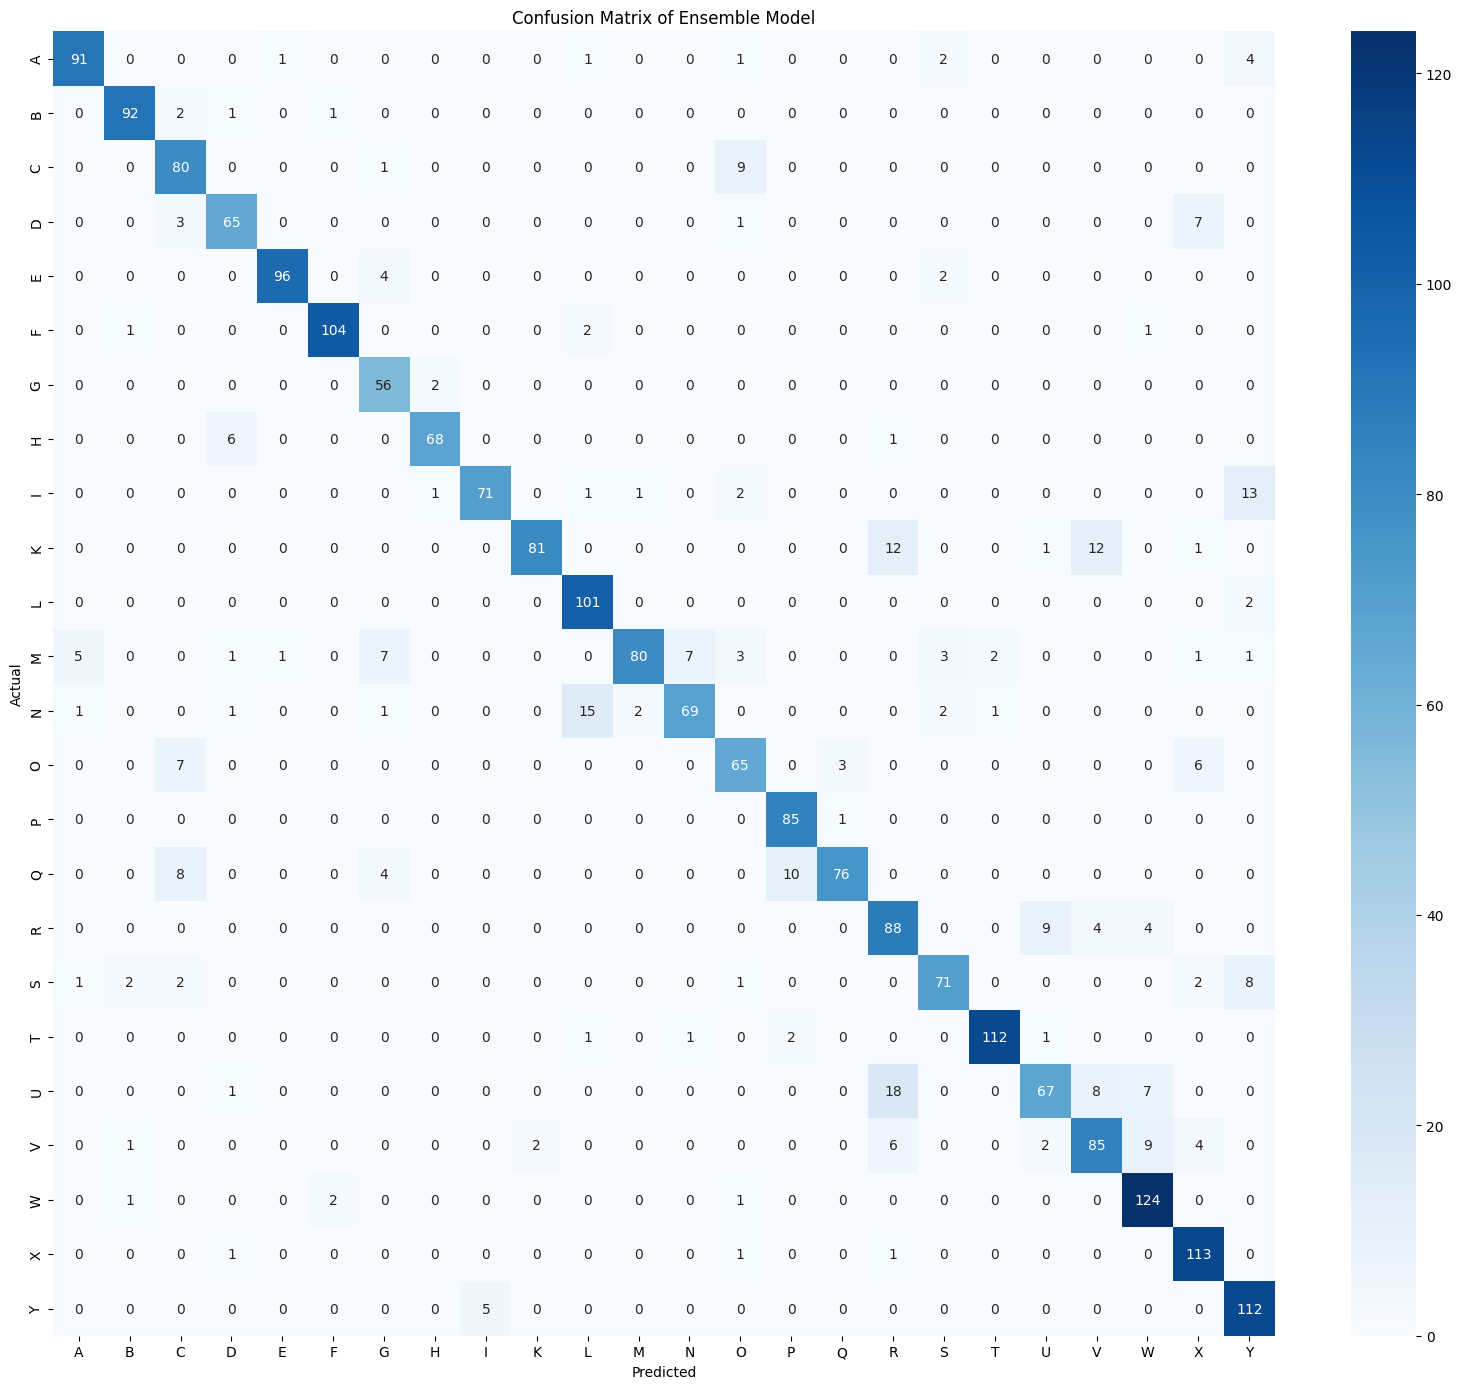

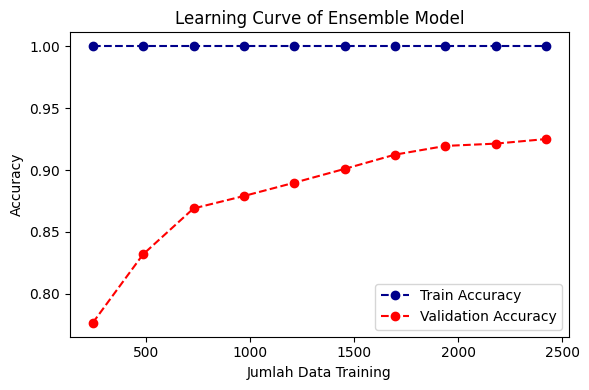

In [26]:
ensemble_model = VotingClassifier(
    estimators = [('KNN', KNN_model), ('RF', RF_model)],
    voting='soft'
)
ensemble_model.fit(x_train, y_train_encode)

acc_ens_train = accuracy_score(y_train_encode, ensemble_model.predict(x_train))
acc_ens_val = accuracy_score(y_val_encode, ensemble_model.predict(x_val))
acc_ens_test = accuracy_score(y_test_encode, ensemble_model.predict(x_test))

print(f"Accuracy Ensemble train: {round(acc_ens_train, 4)}")
print(f"Accuracy Ensemble validation: {round(acc_ens_val, 4)}")
print(f"Accuracy Ensemble test: {round(acc_ens_test, 4)}")

print(f"Classification Report for Ensemble:")
print(classification_report(y_test_encode, ensemble_model.predict(x_test)))

conf_matrix(y_test_encode, ensemble_model.predict(x_test), 'Ensemble')
plot_learning_curve(ensemble_model, x_train, y_train_encode, 'Ensemble')

####Comparison for Training, Validation, and Testing Accuracy

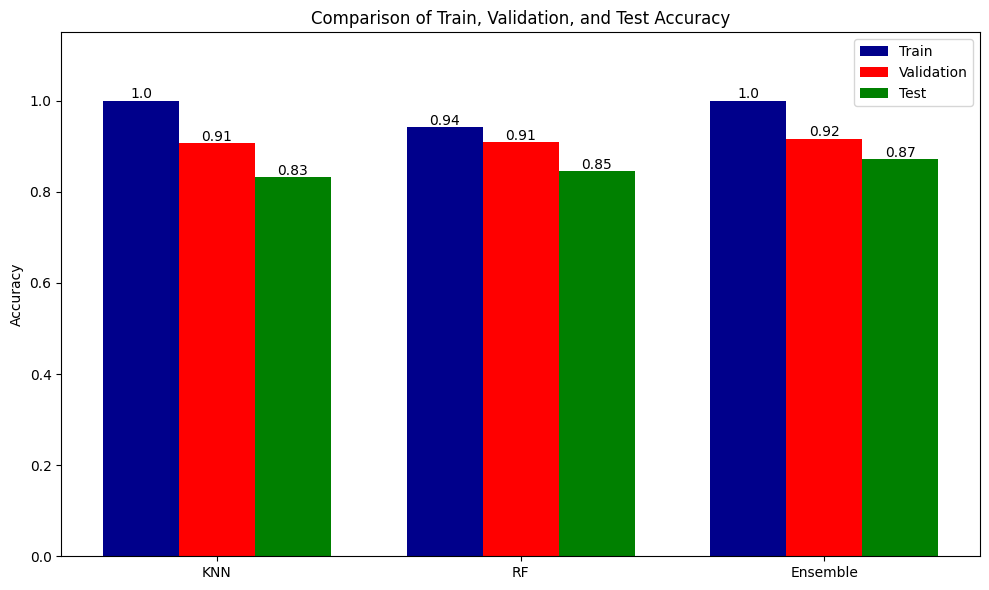

In [27]:
model = ['KNN', 'RF', 'Ensemble']
acc_train = [acc_KNN_train, acc_RF_train, acc_ens_train]
acc_val = [acc_KNN_val, acc_RF_val, acc_ens_val]
acc_test = [acc_KNN_test, acc_RF_test, acc_ens_test]

x_axis = np.arange(len(model))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x_axis - width, acc_train, width, label='Train', color='darkblue')
ax.bar(x_axis, acc_val, width, label='Validation', color='red')
ax.bar(x_axis + width, acc_test, width, label='Test', color='green')

for i, (train, val, test) in enumerate(zip(acc_train, acc_val, acc_test)):
  ax.text(i - width, train + 0.005, f"{round(train, 2)}", ha='center')
  ax.text(i, val + 0.005, f"{round(val, 2)}", ha='center')
  ax.text(i + width, test + 0.005, f"{round(test, 2)}", ha='center')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of Train, Validation, and Test Accuracy')
ax.set_xticks(x_axis)
ax.set_xticklabels(model)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'comparison_acc.png'), dpi=150)
plt.show()

###Save Model

In [28]:
import joblib

In [29]:
for name, model in [('KNN', KNN_model), ('RF', RF_model), ('Ensemble', ensemble_model)]:
  path = os.path.join(MODEL_PATH, f"{name}_Model.pkl")
  joblib.dump(model, path)

In [30]:
joblib.dump(label_encode, os.path.join(MODEL_PATH, "Label_Encoder.pkl"))

['/content/drive/MyDrive/Semester 4/Artificial Intelligence/AOL_SIBI/Model/Label_Encoder.pkl']